# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

*   Student Name:Ian Khoo Rei Jin (Qiu Ruijun)
    
    Student ID: 2501272E
   
    Project Title:  Shopsense, Online Purchase Intention Predictior



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [15]:
## Import libraries
# data handling
import pandas as pd
import numpy as np

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# data preparation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# machine learning models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# save the final model
import joblib



### Library Explanation

Pandas and NumPy are used to load and manipulate the dataset. Matplotlib and Seaborn are used to create visualisations during exploratory data analysis.

Scikit-learn is used for data preprocessing, model training, model evaluation and hyperparameter tuning. Joblib is used to save the final trained model for use in the Streamlit application.

# 1. Business Understanding

#### Business Problem: 

Online retailers receive many website visitors, but not every browsing session results in a purchase. It can be difficult for e-commerce teams to identify which visitors are more likely to buy while they are still browsing. Without this information, businesses may show promotions to users with little purchase intention or miss out on engaging visitors who are close to making a purchase.

#### Project Goal:

The goal of ShopSense is to develop a machine learning classification model that predicts whether an online shopping session is likely to result in a purchase. The model will use information about the visitor's browsing behaviour, such as the number of pages visited, time spent on different page types, bounce rate, exit rate and visitor type.

The predicted outcome is the "Revenue" variable:

- "True"  means the session resulted in a purchase.
- "False" means the session did not result in a purchase.

#### Business Value:

The prediction can help e-commerce teams make better marketing decisions. Visitors with high purchase intention could receive personalised recommendations, limited-time offers or free-shipping reminders. Visitors with low purchase intention could continue browsing normally, allowing the business to avoid using unnecessary promotional resources.

The final model will be included in a Streamlit web application called ShopSense. A business user will enter information about a browsing session, and the application will display the predicted purchase outcome, purchase probability and a simple recommendation.

# 2. Data Understanding

## 2.1 Load dataset

In [16]:
## Read *.csv file into pandas DataFrame
# load the online shopping sessions dataset
df = pd.read_csv("online_shoppers_intention.csv")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Number of rows: 12330
Number of columns: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


#### Dataset Overview:

The dataset contains 12,330 online shopping sessions and 18 columns. Each row represents one visitor session on an e-commerce website.

The target variable is "Revenue". It records whether the browsing session resulted in a purchase:

- "True" means that a purchase occurred.
- "False" means that no purchase occurred.

Since the target has two possible outcomes, this project is a binary classification problem. The remaining 17 columns contain information about the visitor's browsing behaviour, traffic source and session characteristics.

## 2.2 Summary Statistics

In [17]:
## Understand the type of variable for each column
# examine column names, data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

#### Variable Types:

The dataset contains a mixture of numerical, categorical and Boolean variables.

Most browsing measurements, such as the number of pages visited and time spent on pages, are numerical. "Month" and "VisitorType" are categorical variables, while "Weekend" and the target variable "Revenue" are Boolean variables.

The categorical variables will require encoding during data preparation before they can be used by the machine-learning models.

In [18]:
## Check for missing data
# check data quality before preparing the dataset
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values
})

display(missing_summary)

print("Total missing values:", df.isnull().sum().sum())
print("Exact duplicate rows:", df.duplicated().sum())

,Column,Missing Values
0,Administrative,0
1,Administrative_Duration,0
2,Informational,0
3,Informational_Duration,0
4,ProductRelated,0
5,ProductRelated_Duration,0
6,BounceRates,0
7,ExitRates,0
8,PageValues,0
9,SpecialDay,0


Total missing values: 0
Exact duplicate rows: 125


#### Data Quality Findings:

No missing values were found, so missing-value treatment is not required.

However, the dataset contains 125 exact duplicate rows. These duplicates are only identified at this stage. They will be removed later under Data Preparation before the train-test split, as repeated sessions could affect the reliability of the model evaluation.

In [19]:
## Describe data distribution
# summary statistics for numerical variables
print("Numerical variables:")
display(df.describe().T)

# summary statistics for categorical and Boolean variables
print("Categorical and Boolean variables:")

categorical_columns = [
    "Month",
    "VisitorType",
    "Weekend",
    "Revenue"
]

display(df[categorical_columns].describe().T)

Numerical variables:


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


Categorical and Boolean variables:


,count,unique,top,freq
Month,12330,10,May,3364
VisitorType,12330,3,Returning_Visitor,10551
Weekend,12330,2,False,9462
Revenue,12330,2,False,10422


#### Summary Statistics Interpretation:

Several browsing variables have maximum values that are much larger than their median values. For example, some visitors spent considerably more time on product-related pages than a typical visitor. This indicates that variables such as page counts and browsing duration are right-skewed and contain possible outliers.

These large values are not automatically treated as errors because they may represent genuine highly engaged visitors. Their distributions will be examined further using visualisations before any data-preparation decisions are made.

The categorical summary also shows that most sessions belong to returning visitors and that most sessions did not result in a purchase.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

,Count,Percentage
No Purchase,10422,84.53
Purchase,1908,15.47


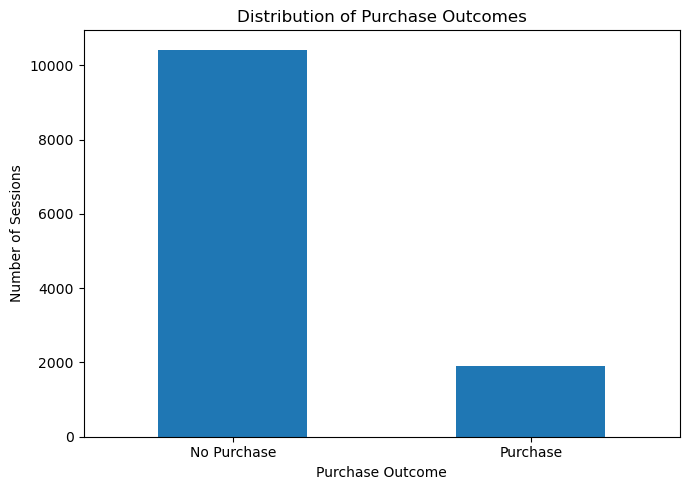

In [20]:
## Understanding distribution of target
# calculate the number and percentage of purchase outcomes
target_counts = df["Revenue"].value_counts().reindex([False, True])
target_percentages = (
    df["Revenue"]
    .value_counts(normalize=True)
    .reindex([False, True])
    * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts.values,
    "Percentage": target_percentages.values
}, index=["No Purchase", "Purchase"])

display(target_summary.round(2))

# visualise the target distribution
target_summary["Count"].plot(kind="bar", figsize=(7, 5))

plt.title("Distribution of Purchase Outcomes")
plt.xlabel("Purchase Outcome")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Target Distribution Interpretation:

The target variable is imbalanced. Approximately 84.5% of the shopping sessions did not result in a purchase, while only around 15.5% resulted in a purchase.

This means that accuracy alone may be misleading. A model that predicts most sessions as non-purchases could obtain high accuracy while failing to identify genuine buyers.

A stratified train-test split should therefore be used later to preserve the target proportions. Metrics such as precision, recall and F1-score should also be considered when evaluating the models.

### 2.3.1.2 Understanding distribution of features

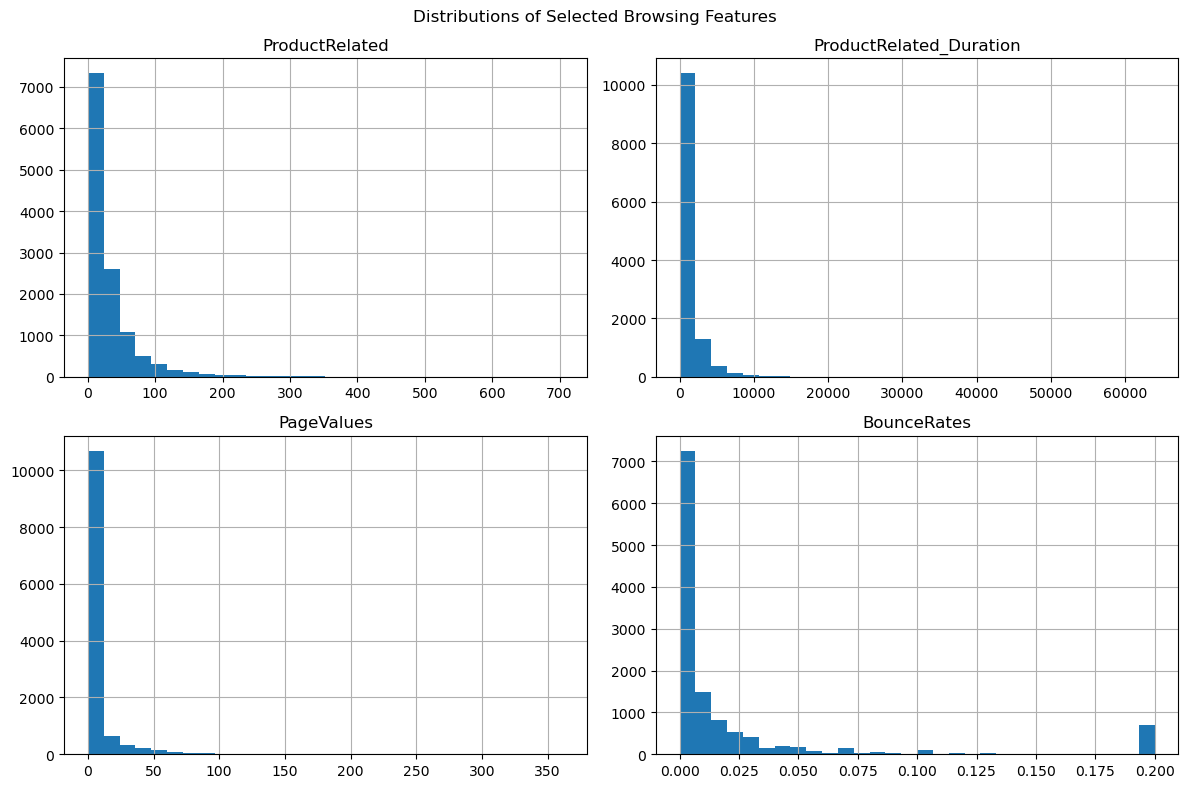

In [21]:

# examine the distributions of important browsing variables
features_to_plot = [
    "ProductRelated",
    "ProductRelated_Duration",
    "PageValues",
    "BounceRates"
]

df[features_to_plot].hist(
    bins=30,
    figsize=(12, 8)
)

plt.suptitle("Distributions of Selected Browsing Features")
plt.tight_layout()
plt.show()

#### Feature Distribution Interpretation:

The selected browsing features are not normally distributed.

"ProductRelated" and "ProductRelated_Duration" are right-skewed because most visitors browse a moderate number of product pages, while a smaller number spend much longer on the website.

"PageValues" contains many zero values. This means many sessions did not reach pages that had measurable value towards completing a transaction.

"BounceRates" is concentrated near zero, although some sessions have considerably higher bounce rates. These skewed distributions and possible outliers may affect some algorithms, particularly models that are sensitive to feature scale.

### 2.3.2 Understanding relationship between variables

### Relationship 1 — Visitor type and purchase rate

,Purchase Rate (%)
VisitorType,
New_Visitor,24.91
Other,18.82
Returning_Visitor,13.93


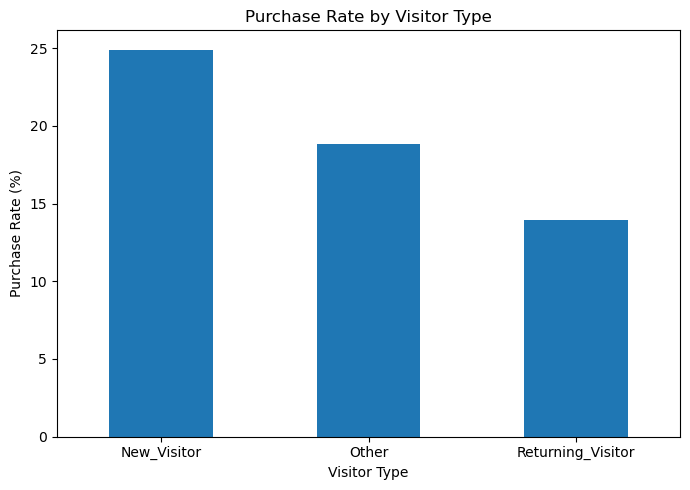

In [22]:


purchase_rate_by_visitor = ( ## calculate purchase rate for each visitor type
    df.groupby("VisitorType")["Revenue"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

display(purchase_rate_by_visitor.round(2).to_frame("Purchase Rate (%)"))

purchase_rate_by_visitor.plot(kind="bar", figsize=(7, 5))

plt.title("Purchase Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Visitor Type Interpretation:

New visitors have the highest purchase rate at approximately 24.9%, compared with approximately 13.9% for returning visitors.

However, returning visitors make up most of the dataset. Therefore, the purchase rate should be interpreted together with the number of sessions rather than assuming that new visitors generate the largest number of purchases.

"VisitorType" may be useful for prediction and will require categorical encoding during data preparation.

### Relationship 2 — Page value and purchase outcome

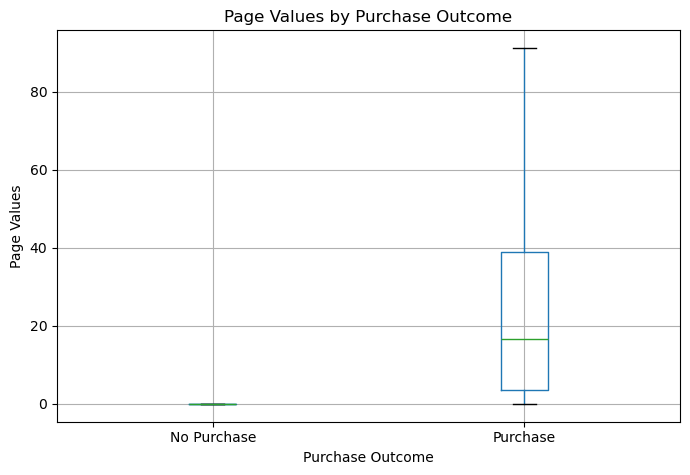

,mean,median
Revenue,,
No Purchase,1.975998,0.000000
Purchase,27.264518,16.758134


In [23]:


page_value_plot = df.copy() # create readable labels for the target

page_value_plot["PurchaseOutcome"] = page_value_plot["Revenue"].map({
    False: "No Purchase",
    True: "Purchase"
})

# hide extreme points only in the graph so the main distribution is readable
page_value_plot.boxplot(
    column="PageValues",
    by="PurchaseOutcome",
    showfliers=False,
    figsize=(7, 5)
)

plt.suptitle("")
plt.title("Page Values by Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Page Values")
plt.tight_layout()
plt.show()

# numerical comparison to support the graph
display(
    df.groupby("Revenue")["PageValues"]
    .agg(["mean", "median"])
    .rename(index={False: "No Purchase", True: "Purchase"})
)

#### Page Value Interpretation:

Sessions that resulted in purchases generally have much higher "PageValues" than sessions that did not result in purchases.

The average Page Value is approximately 27.26 for purchase sessions but only approximately 1.98 for non-purchase sessions. The median Page Value for non-purchase sessions is 0, while the median is considerably higher at about 16.76 for purchase sessions.

This suggests that "PageValues" could be important to predict purchase intention. Outliers were hidden only to make the boxplot readable. No records have been removed from the dataset.

### Relationship 3 — Correlation heatmap

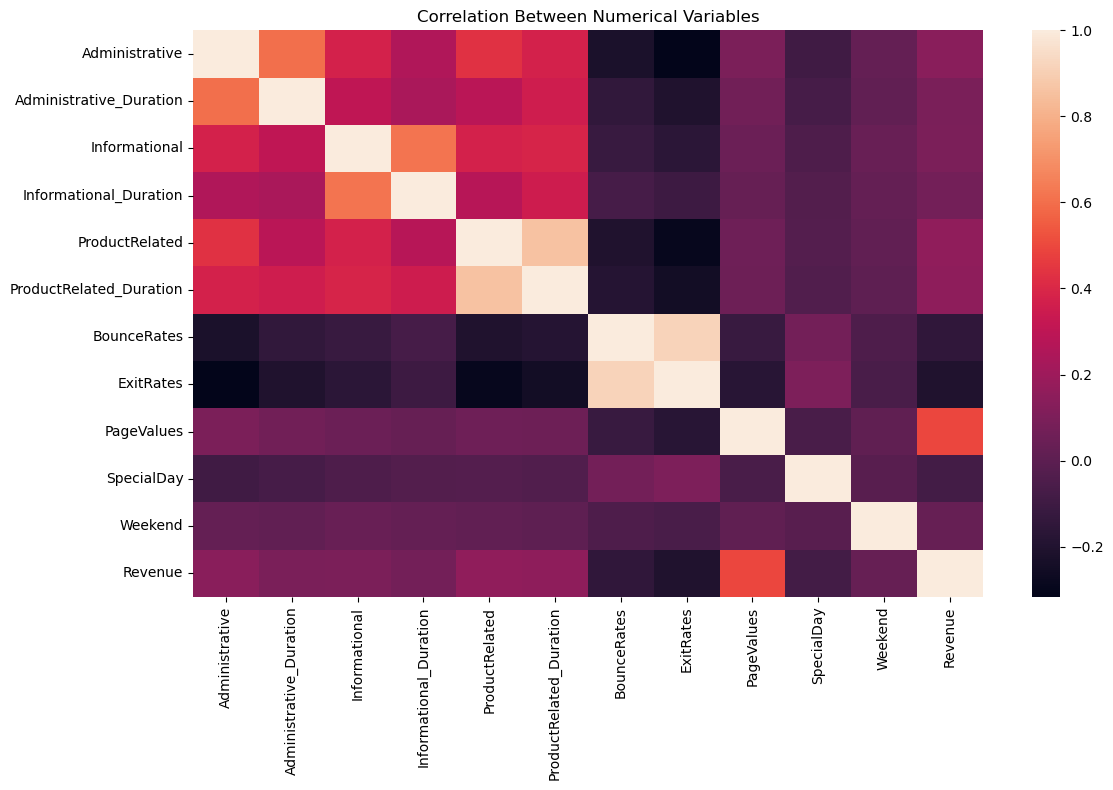

,Correlation with Revenue
Revenue,1.000000
PageValues,0.492569
ProductRelated,0.158538
ProductRelated_Duration,0.152373
Administrative,0.138917
Informational,0.095200
Administrative_Duration,0.093587
Informational_Duration,0.070345
Weekend,0.029295
SpecialDay,-0.082305


In [24]:

# select genuinely numerical browsing variables for correlation analysis
correlation_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Weekend",
    "Revenue"
]

correlation_df = df[correlation_columns].copy()

# temporarily convert Boolean variables to 0 and 1
correlation_df["Revenue"] = correlation_df["Revenue"].astype(int)
correlation_df["Weekend"] = correlation_df["Weekend"].astype(int)

correlation_matrix = correlation_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=False
)

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

# display each feature's correlation with Revenue
revenue_correlations = (
    correlation_matrix["Revenue"]
    .sort_values(ascending=False)
    .to_frame("Correlation with Revenue")
)

display(revenue_correlations)

#### Correlation Interpretation:

"PageValues" has the greatest positive numerical relationship with "Revenue", with a correlation of approximately 0.49.

"ProductRelated" and "ProductRelated_Duration" have weaker positive relationships with the target at 0.16 and 0.15 respectively. This suggests that visitors who view more product pages or spend more time browsing products may be more likely to purchase.

"ExitRates" and "BounceRates" has the greatest negative relationships with "Revenue" at -0.21 and -0.15 respectively. Sessions with higher exit or bounce rates are generally less likely to result in purchases.

Correlation is not the same as causation which means that it does not prove that one variable causes another. However, these findings identify useful features that should be retained for model development.

# 3. Data Preparation

## 3.1 Data Cleaning

In [25]:
## Clean data

## 3.2 Train-Test Split

In [26]:
## Split data into train set and test set


# 4. Modelling

### 4.2 Train Model

In [27]:
## Initialise and train model


# 5. Model Evaluation

In [28]:
## Evaluate model


In [29]:
## New data

## Predict


## Iterative model development


In [30]:
## Further feature engineering / feature selection